In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Drop missing values
df = df.dropna()

# Encode categorical columns
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Split data
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Evaluate
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4942
           1       0.75      0.64      0.69      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.79      0.80      6513
weighted avg       0.86      0.86      0.86      6513



In [4]:
import numpy as np

def add_label_noise(y, noise_level=0.1):
    y_noisy = y.copy()
    n_samples = int(len(y) * noise_level)
    
    noise_indices = np.random.choice(len(y), n_samples, replace=False)
    
    for idx in noise_indices:
        y_noisy.iloc[idx] = 1 - y_noisy.iloc[idx]  # flip label (0 → 1, 1 → 0)
    
    return y_noisy

In [6]:
noise_level = 0.2  # 20% noise

y_train_noisy = add_label_noise(y_train, noise_level)

model_noisy = RandomForestClassifier(random_state=42)
model_noisy.fit(X_train, y_train_noisy)

preds_noisy = model_noisy.predict(X_test)

print("Results with noise:")
print(classification_report(y_test, preds_noisy))

Results with noise:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      4942
           1       0.68      0.64      0.66      1571

    accuracy                           0.84      6513
   macro avg       0.78      0.77      0.78      6513
weighted avg       0.84      0.84      0.84      6513



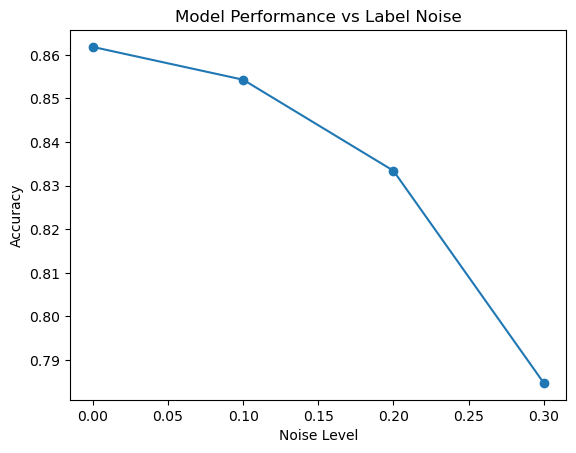

In [8]:
noise_levels = [0.0, 0.1, 0.2, 0.3]
accuracies = []

for noise in noise_levels:
    y_train_noisy = add_label_noise(y_train, noise)
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train_noisy)
    
    preds = model.predict(X_test)
    
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

import matplotlib.pyplot as plt

plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Model Performance vs Label Noise")
plt.show()

In [10]:
import pandas as pd

# Compare predictions vs truth
results_df = X_test.copy()
results_df["true"] = y_test
results_df["pred"] = preds

# Find errors
errors = results_df[results_df["true"] != results_df["pred"]]

# Look at most common errors
print(errors.head())

# Analyze patterns
print("\nError distribution by sex:")
print(errors["sex"].value_counts())

print("\nError distribution by education:")
print(errors["education"].value_counts())

       age  workclass  fnlwgt  education  education-num  marital-status  \
27048   45          7   50567         11              9               2   
15382   51          4  108435         12             14               2   
4641    58          6   93664         11              9               2   
20010   41          4  152529          9             13               4   
8966    43          4   99212          8             11               2   

       occupation  relationship  race  sex  capital-gain  capital-loss  \
27048           4             5     4    0             0             0   
15382          10             0     4    1             0             0   
4641            4             0     4    1         15024             0   
20010          10             1     4    1             0             0   
8966            4             0     4    1          3103             0   

       hours-per-week  native-country  true  pred  
27048              40              39     0     1  


In [ ]:
## Key Findings

1. Model performance decreases as label noise increases, confirming sensitivity to data quality.

2. Performance degradation is nonlinear, with a sharp decline beyond moderate noise levels (~20–30%).

3. The model exhibits asymmetric error behavior, with significantly lower recall for the high-income class.

4. Errors are not randomly distributed:
   - Certain demographic groups experience higher error rates
   - Specific education levels show concentrated prediction failures

5. These results suggest that model reliability in real-world systems depends heavily on both data quality and feature distribution.